# 01. EDA + Baseline ML (01_eda_baseline.ipynb)

## 개요

| 섹션 | 내용 |
|------|------|
| EDA | 타겟 분포, 피처 분포, 상관관계, 이상치 분석 |
| Baseline ML | Linear / Ridge / Lasso / RandomForest 회귀 + 분류 |

## 입력 / 출력

| 구분 | 경로 |
|------|------|
| 입력 | `data/processed/feature_table_v1.csv` |
| 차트 저장 | `images/01_eda/` |
| 결과 요약 | 마지막 셀 마크다운 |

> 피처 버전을 바꾸려면 셀 0의 `VERSION`만 수정하세요.

---
## ⚙️ 셀 0. 환경 설정

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import koreanize_matplotlib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ── 설정 ────────────────────────────────────────────
VERSION    = 'v1'
DATA_PATH  = f'process/data/processed/feature_table_{VERSION}.csv'
IMAGE_DIR  = 'images/01_eda'
RANDOM_STATE = 42
TEST_YEAR    = 2023   # 이 연도 이후를 test set으로 사용 (시간 기준 분할)
# ────────────────────────────────────────────────────

os.makedirs(IMAGE_DIR, exist_ok=True)

# ── 한글 폰트 자동 설정 ──
import platform
import matplotlib.font_manager as fm

def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic']
    elif system == 'Darwin':
        candidates = ['AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR', 'UnDotum']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f'✅ 한글 폰트 설정: {font}')
            return
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ['Gothic', 'Nanum', 'Noto', 'Batang', 'Dotum']):
            plt.rcParams['font.family'] = f.name
            print(f'✅ 한글 폰트 설정(탐색): {f.name}')
            return
    print('⚠️  한글 폰트 없음 → uv add koreanize-matplotlib 후 import koreanize_matplotlib 추가')

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print(f'✅ 설정 완료  |  버전: {VERSION}  |  test 기준 연도: {TEST_YEAR}년~')

✅ 한글 폰트 설정: Malgun Gothic
✅ 설정 완료  |  버전: v1  |  test 기준 연도: 2023년~


---
## 📥 셀 1. 데이터 로드 및 기본 확인

In [5]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# open_date 복원 (CSV 저장 시 문자열로 변환됨)
# feature_table에 open_date가 없으므로 open_month/open_day_of_week로 연도 확인 불가
# → movie_id 기준 연도 정보를 별도로 DB에서 가져오거나, open_year 컬럼 활용
# ※ 00_feature_table에서 open_year를 저장했다면 아래 사용
if 'open_year' not in df.columns:
    print('⚠️  open_year 컬럼 없음 → 시간 기준 분할 불가, 랜덤 분할로 대체')
    TIME_SPLIT = False
else:
    TIME_SPLIT = True

print(f'shape : {df.shape[0]}행 × {df.shape[1]}열')
print(f'\n결측치:\n{df.isna().sum()[df.isna().sum()>0].to_string() if df.isna().any().any() else "없음"}')
print(f'\ndtype 요약:')
print(df.dtypes.value_counts().to_string())
df.head(3)

⚠️  open_year 컬럼 없음 → 시간 기준 분할 불가, 랜덤 분할로 대체
shape : 3904행 × 26열

결측치:
없음

dtype 요약:
int64      13
float64    10
str         3


,movie_id,title,runtime,rating_encoded,is_korean,genre,open_month,open_day_of_week,is_summer,is_winter,...,cast_max_star_power,distributor_avg_audi,distributor_movie_count,producer_avg_audi,producer_movie_count,same_week_releases,market_avg_audi_7d,total_audience,log_audience,hit_class
0,20090077,전우치,136.0,1,1,액션,12.0,2.0,0,1,...,2546967.0,782656.857143,7,0.0,0,0,377401.214286,6047715,15.615191,3
1,20090089,파르나서스 박사의 상상극장,122.0,1,0,판타지,12.0,2.0,0,1,...,4271842.0,0.000000,0,0.0,0,0,377401.214286,453536,13.024832,1
2,20090685,2012,157.0,1,0,SF,11.0,3.0,0,0,...,0.0,125122.000000,4,0.0,0,0,377401.214286,5395350,15.501048,3


---
## 🔍 셀 2. 타겟 변수 분포 시각화

- `total_audience` 원본 분포와 `log_audience` 변환 후 분포를 비교합니다
- 왜도(skewness)가 크면 log 변환이 효과적임을 확인합니다

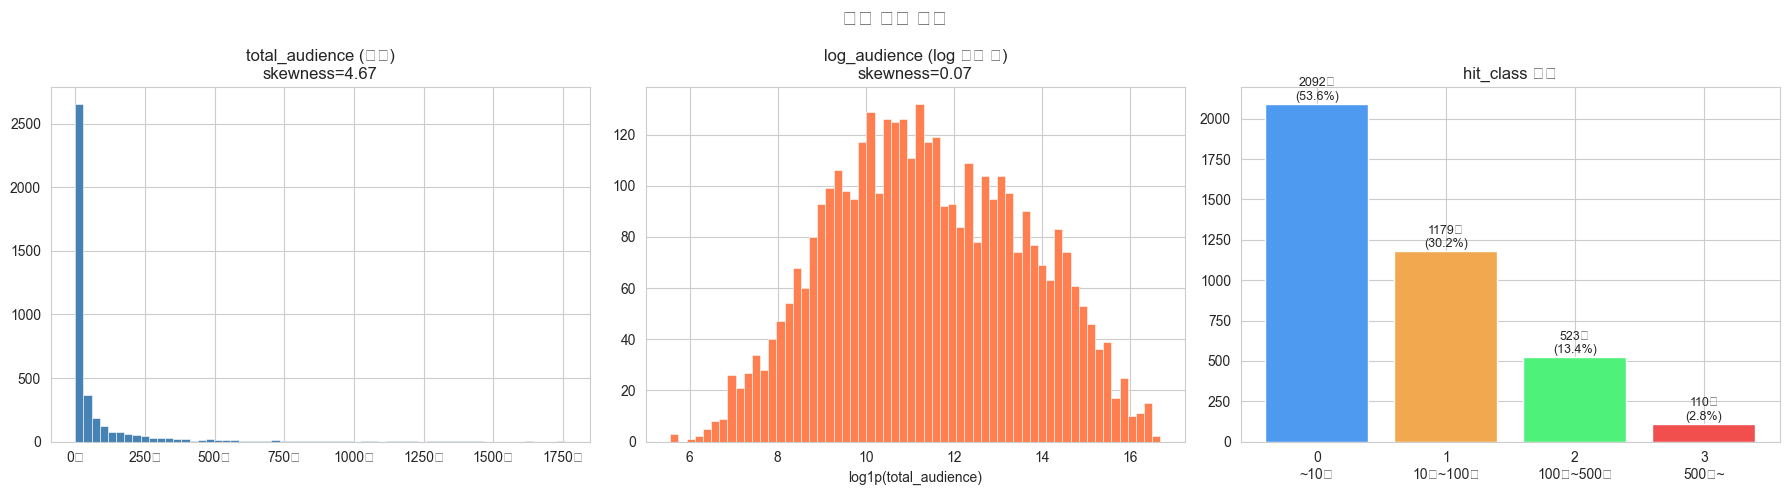


총 관객수 기술통계:
count         3,904
mean        663,212
std       1,602,243
min             259
25%          17,598
50%          79,188
75%         486,703
max      17,583,608
Name: total_audience, dtype: str


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타겟 변수 분포', fontsize=15, fontweight='bold')

# 1) total_audience 원본
axes[0].hist(df['total_audience'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title(f'total_audience (원본)\nskewness={df["total_audience"].skew():.2f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))

# 2) log_audience
axes[1].hist(df['log_audience'], bins=60, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_title(f'log_audience (log 변환 후)\nskewness={df["log_audience"].skew():.2f}')
axes[1].set_xlabel('log1p(total_audience)')

# 3) hit_class 막대
label_map = {0:'0\n~10만', 1:'1\n10만~100만', 2:'2\n100만~500만', 3:'3\n500만~'}
vc = df['hit_class'].value_counts().sort_index()
bars = axes[2].bar([label_map[i] for i in vc.index], vc.values,
                   color=['#4e9af1','#f1a84e','#4ef17a','#f14e4e'])
axes[2].set_title('hit_class 분포')
for bar, val in zip(bars, vc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}편\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n총 관객수 기술통계:')
print(df['total_audience'].describe().apply(lambda x: f'{x:,.0f}'))

---
## 📊 셀 3. 범주형 피처 분포 및 흥행 관계

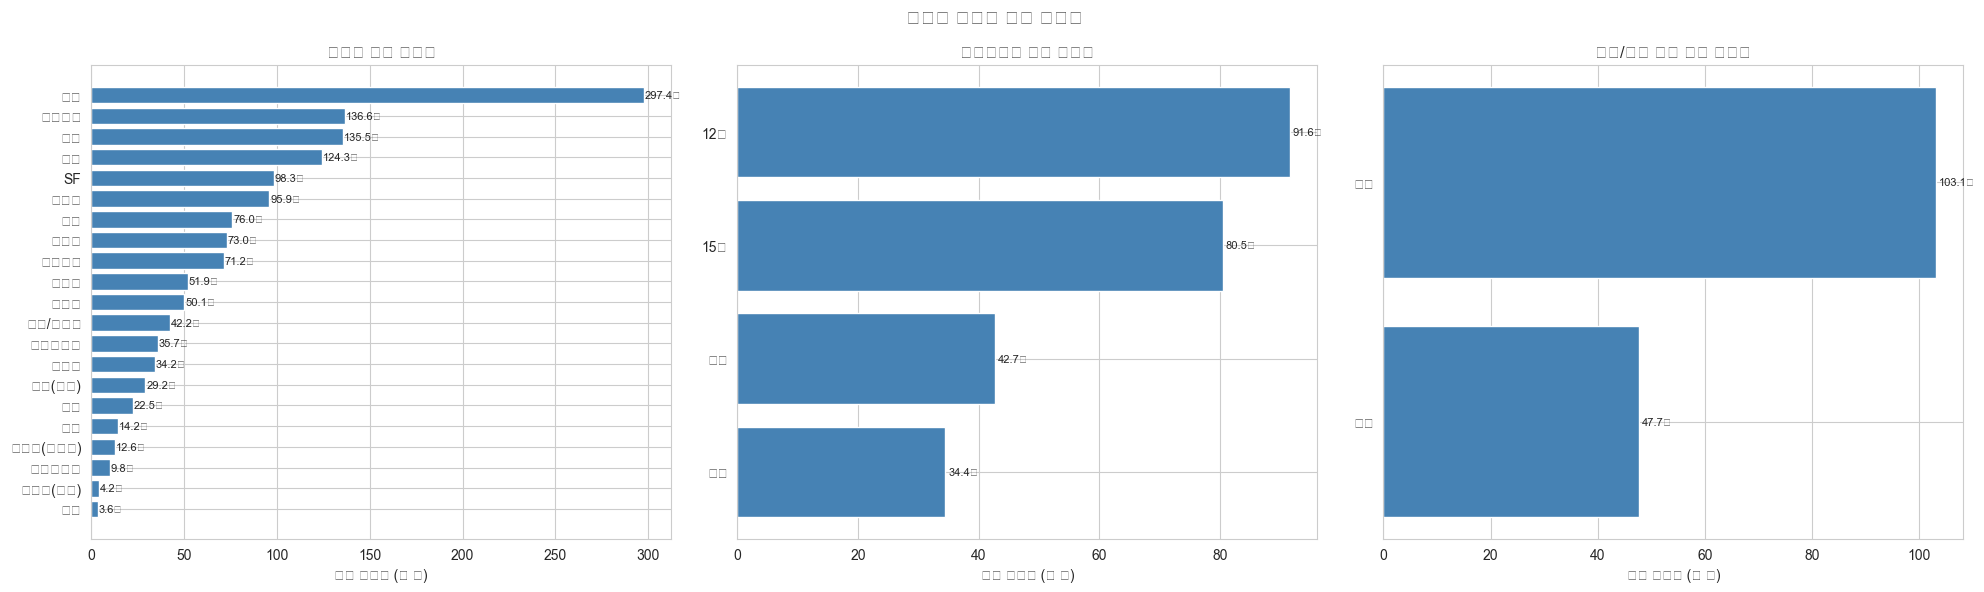

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('범주형 피처별 평균 관객수', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['genre', 'rating_encoded', 'is_korean'],
    ['장르별 평균 관객수', '관람등급별 평균 관객수', '한국/외국 영화 평균 관객수']
):
    group = df.groupby(col)['total_audience'].mean().sort_values(ascending=True)

    if col == 'rating_encoded':
        rating_label = {0:'전체', 1:'12세', 2:'15세', 3:'청불', 4:'제한'}
        group.index = [rating_label.get(i, str(i)) for i in group.index]
    elif col == 'is_korean':
        group.index = ['외국', '한국']

    bars = ax.barh(group.index.astype(str), group.values / 1e4, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('평균 관객수 (만 명)')
    for bar, val in zip(bars, group.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val/1e4:.1f}만', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/02_category_vs_audience.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📅 셀 4. 시간/계절 피처 분석

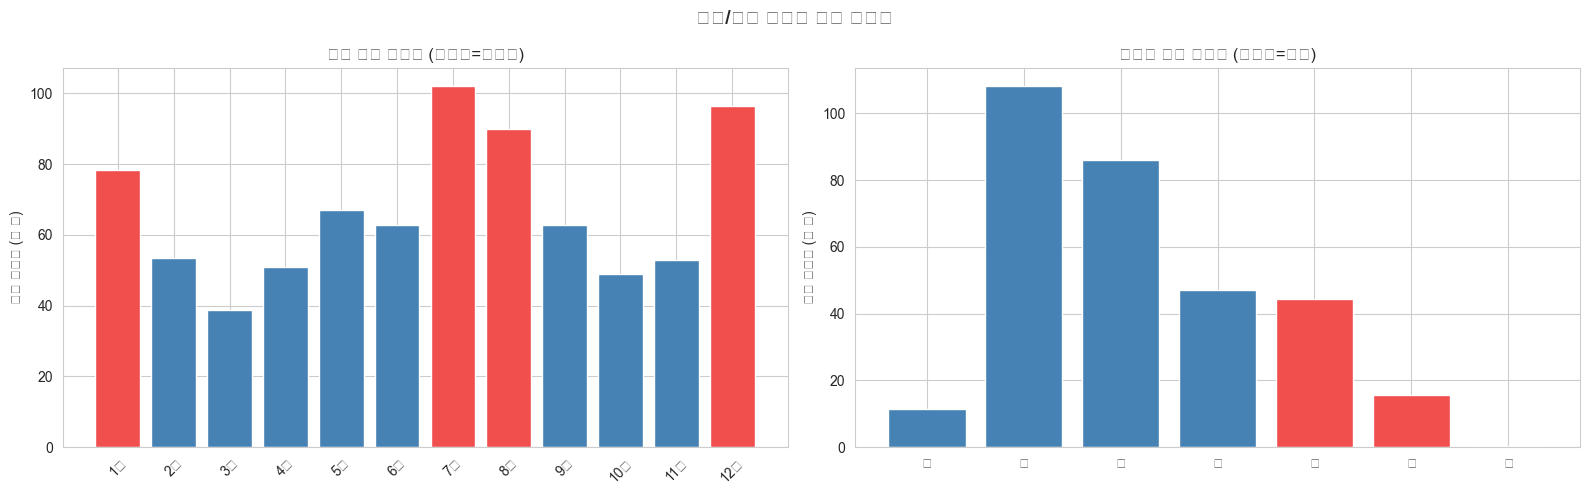

공휴일 개봉 여부별 평균 관객수:
                       mean  count
is_holiday_release                
비공휴일                657,644  3,716
공휴일                 773,271    188


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('시간/계절 피처와 평균 관객수', fontsize=14, fontweight='bold')

# 월별 평균 관객수
month_avg = df.groupby('open_month')['total_audience'].mean()
month_label = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
axes[0].bar(month_label, [month_avg.get(i, 0)/1e4 for i in range(1,13)],
            color=['#f14e4e' if i in [7,8,12,1] else 'steelblue' for i in range(1,13)])
axes[0].set_title('월별 평균 관객수 (빨간색=성수기)')
axes[0].set_ylabel('평균 관객수 (만 명)')
axes[0].tick_params(axis='x', rotation=45)

# 요일별 평균 관객수
dow_avg   = df.groupby('open_day_of_week')['total_audience'].mean()
dow_label = ['월','화','수','목','금','토','일']
axes[1].bar(dow_label, [dow_avg.get(i, 0)/1e4 for i in range(7)],
            color=['#f14e4e' if i >= 4 else 'steelblue' for i in range(7)])
axes[1].set_title('요일별 평균 관객수 (빨간색=주말)')
axes[1].set_ylabel('평균 관객수 (만 명)')

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/03_time_season_vs_audience.png', dpi=150, bbox_inches='tight')
plt.show()

# 공휴일 효과
print('공휴일 개봉 여부별 평균 관객수:')
print(df.groupby('is_holiday_release')['total_audience']
      .agg(['mean','count'])
      .rename(index={0:'비공휴일', 1:'공휴일'})
      .map(lambda x: f'{x:,.0f}'))

---
## 🌟 셀 5. Star Power / Brand Power 분포 및 0값 비율

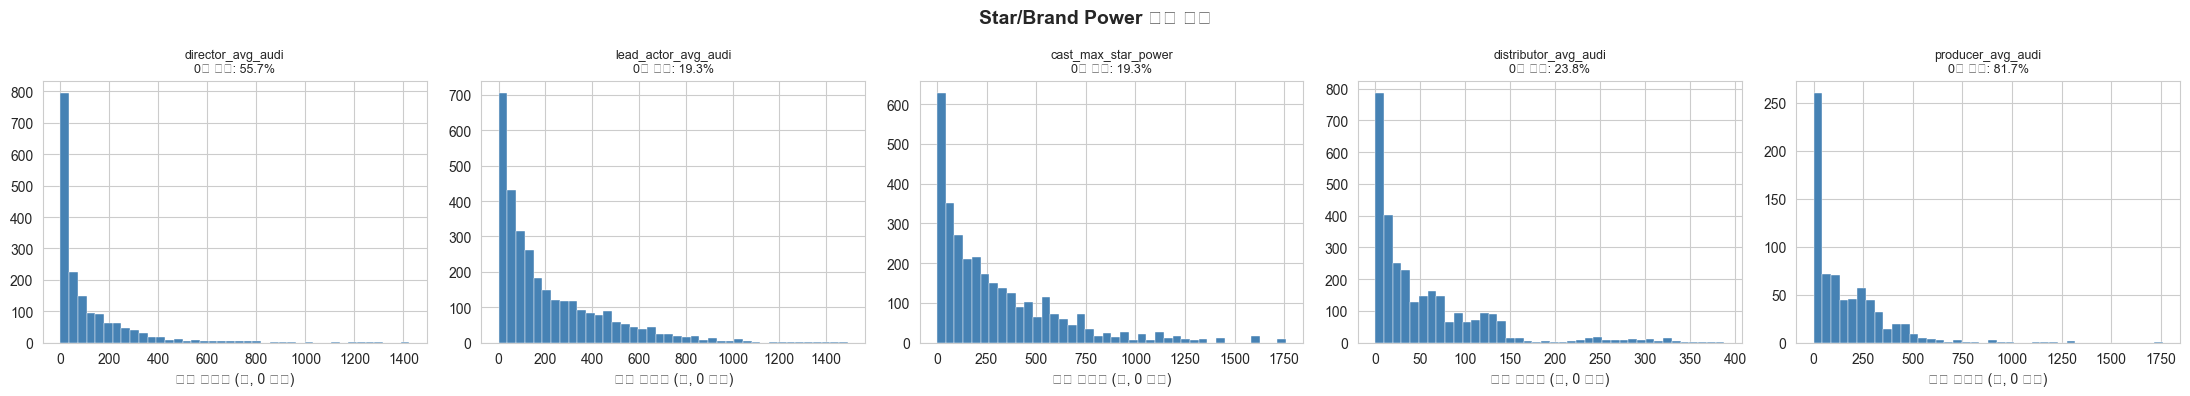


Star/Brand Power 0값 비율 요약:
  ✅ director_avg_audi: 55.7%
  ✅ lead_actor_avg_audi: 19.3%
  ✅ cast_max_star_power: 19.3%
  ✅ distributor_avg_audi: 23.8%
  ⚠️  producer_avg_audi: 81.7%


In [9]:
power_cols = [
    'director_avg_audi', 'lead_actor_avg_audi', 'cast_max_star_power',
    'distributor_avg_audi', 'producer_avg_audi'
]

fig, axes = plt.subplots(1, len(power_cols), figsize=(22, 4))
fig.suptitle('Star/Brand Power 피처 분포', fontsize=14, fontweight='bold')

for ax, col in zip(axes, power_cols):
    nonzero = df[df[col] > 0][col]
    zero_pct = (df[col] == 0).mean() * 100
    ax.hist(nonzero / 1e4, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}\n0값 비율: {zero_pct:.1f}%', fontsize=9)
    ax.set_xlabel('평균 관객수 (만, 0 제외)')

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/04_star_brand_power_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStar/Brand Power 0값 비율 요약:')
for col in power_cols:
    zero_pct = (df[col] == 0).mean()
    flag = '⚠️ ' if zero_pct > 0.7 else '✅'
    print(f'  {flag} {col}: {zero_pct:.1%}')

---
## 🔥 셀 6. 피처-타겟 상관관계 히트맵

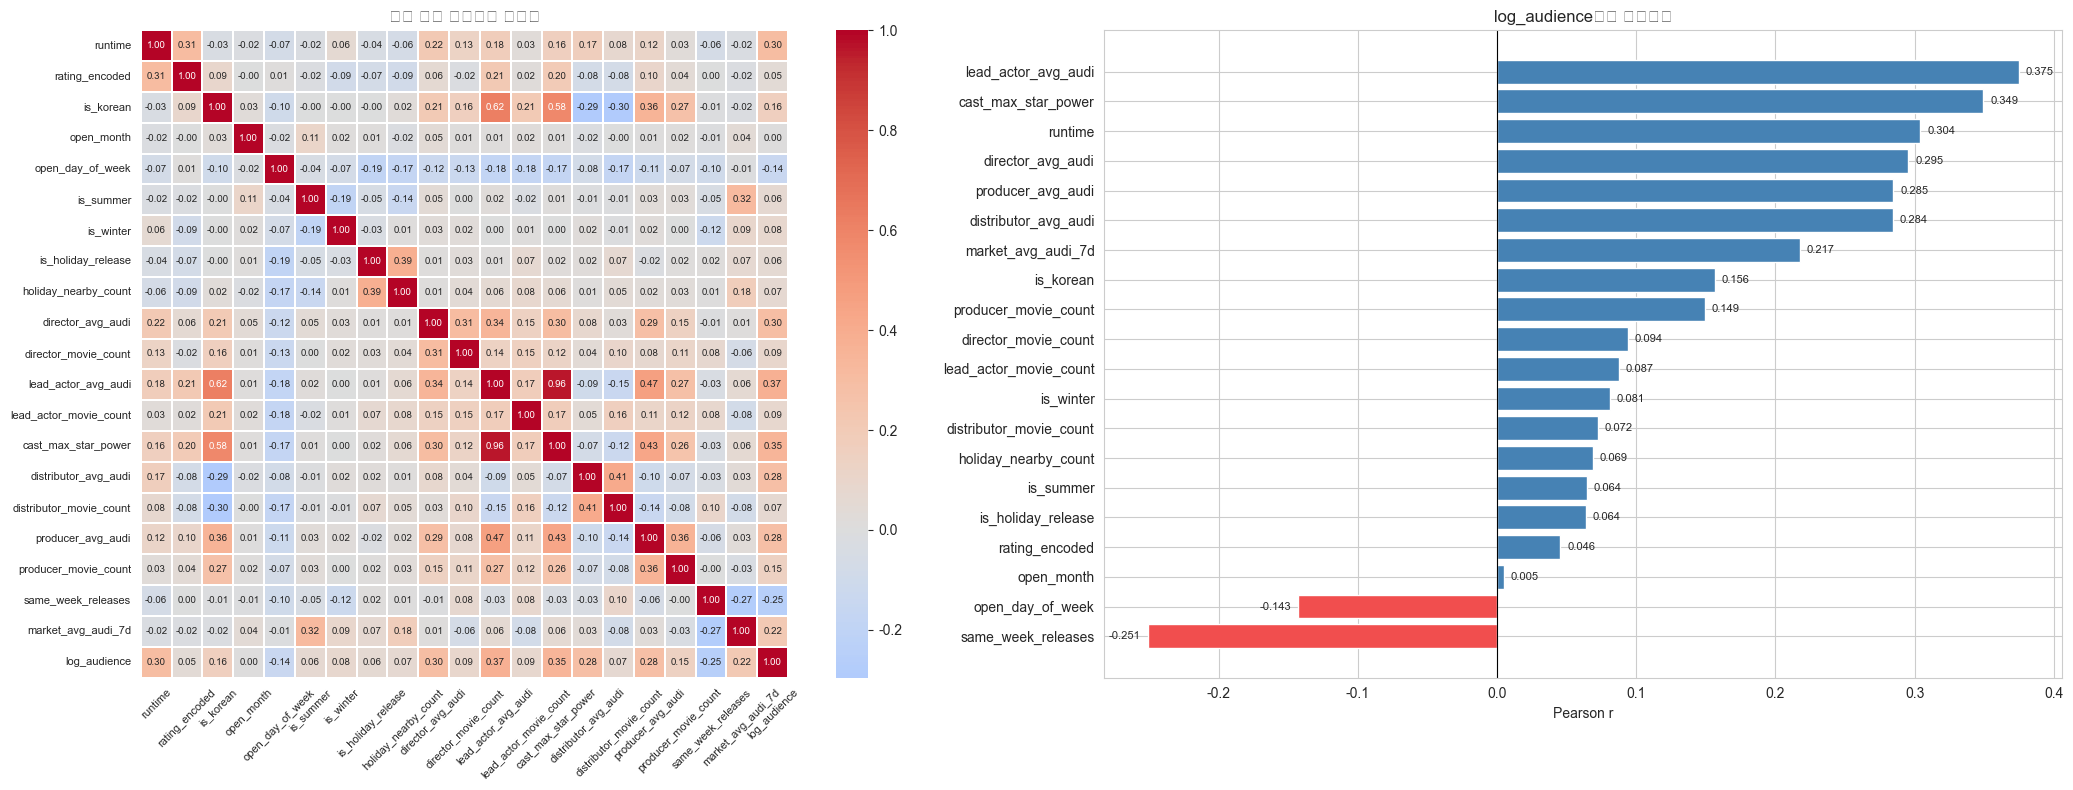


log_audience와 상관계수 TOP 5 (절대값):
lead_actor_avg_audi    0.3747
cast_max_star_power    0.3493
runtime                0.3042
director_avg_audi      0.2955
producer_avg_audi      0.2847
Name: log_audience, dtype: str


In [10]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# ID성 컬럼 및 중복 타겟 제거
exclude  = ['total_audience', 'hit_class']
num_cols = [c for c in num_cols if c not in exclude]

corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# 전체 히트맵
sns.heatmap(corr, ax=axes[0], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, square=True)
axes[0].set_title('피처 전체 상관관계 히트맵', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# log_audience와의 상관계수 막대
corr_target = corr['log_audience'].drop('log_audience').sort_values()
colors = ['#f14e4e' if v < 0 else 'steelblue' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('log_audience와의 상관계수', fontsize=12)
axes[1].set_xlabel('Pearson r')
for i, (idx, val) in enumerate(corr_target.items()):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nlog_audience와 상관계수 TOP 5 (절대값):')
print(corr_target.abs().sort_values(ascending=False).head(5).apply(lambda x: f'{x:.4f}'))

---
## ✂️ 셀 7. Train / Test 분할

- `open_year` 컬럼이 있으면 시간 기준 분할 (권장)
- 없으면 랜덤 8:2 분할

In [11]:
# ── 피처 정의 ──
# genre는 문자열 → OneHotEncoder로 처리
CAT_COLS = ['genre']
NUM_COLS = [
    'runtime', 'rating_encoded', 'is_korean',
    'open_month', 'open_day_of_week', 'is_summer', 'is_winter',
    'is_holiday_release', 'holiday_nearby_count',
    'director_avg_audi', 'director_movie_count',
    'lead_actor_avg_audi', 'lead_actor_movie_count', 'cast_max_star_power',
    'distributor_avg_audi', 'distributor_movie_count',
    'producer_avg_audi', 'producer_movie_count',
    'same_week_releases', 'market_avg_audi_7d'
]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

FEATURE_COLS = CAT_COLS + NUM_COLS
TARGET_REG   = 'log_audience'
TARGET_CLS   = 'hit_class'

X = df[FEATURE_COLS]
y_reg = df[TARGET_REG]
y_cls = df[TARGET_CLS]

# ── 분할 ──
if TIME_SPLIT and 'open_year' in df.columns:
    train_mask = df['open_year'] < TEST_YEAR
    X_train, X_test   = X[train_mask],   X[~train_mask]
    yr_train, yr_test = y_reg[train_mask], y_reg[~train_mask]
    yc_train, yc_test = y_cls[train_mask], y_cls[~train_mask]
    print(f'✅ 시간 기준 분할  |  train: {TEST_YEAR}년 이전 {len(X_train)}편  |  test: {TEST_YEAR}년~ {len(X_test)}편')
else:
    X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
        X, y_reg, y_cls, test_size=0.2, random_state=RANDOM_STATE
    )
    print(f'✅ 랜덤 분할  |  train: {len(X_train)}편  |  test: {len(X_test)}편')

# ── 전처리 파이프라인 ──
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])
print(f'\n피처 수: 수치형 {len(NUM_COLS)}개 + 범주형 {len(CAT_COLS)}개')

✅ 랜덤 분할  |  train: 3123편  |  test: 781편

피처 수: 수치형 20개 + 범주형 1개


---
## 📈 셀 8. 회귀 모델 학습 (Linear / Ridge / Lasso / RandomForest)

타겟: `log_audience` → 예측 후 `expm1()`로 실제 관객수 복원

In [12]:
reg_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (α=1.0)'     : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso (α=0.1)'     : Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
    'RandomForest'      : RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

reg_results = {}

for name, model in reg_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, yr_train)
    pred_log = pipe.predict(X_test)

    # log 스케일 지표
    rmse_log = np.sqrt(mean_squared_error(yr_test, pred_log))
    mae_log  = mean_absolute_error(yr_test, pred_log)
    r2       = r2_score(yr_test, pred_log)

    # 실제 관객수 복원 후 지표
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(yr_test)
    rmse_real = np.sqrt(mean_squared_error(true_real, pred_real))
    mae_real  = mean_absolute_error(true_real, pred_real)

    reg_results[name] = {
        'RMSE(log)': rmse_log, 'MAE(log)': mae_log, 'R²': r2,
        'RMSE(실제)': rmse_real, 'MAE(실제)': mae_real,
        'pipe': pipe
    }
    print(f'[{name}]  R²={r2:.4f}  RMSE(log)={rmse_log:.4f}  MAE(실제)={mae_real/1e4:.1f}만명')

# 결과 표
df_reg_result = pd.DataFrame([
    {'모델': k, 'R²': f'{v["R²"]:.4f}',
     'RMSE(log)': f'{v["RMSE(log)"]:.4f}',
     'MAE(실제관객수)': f'{v["MAE(실제)"]/1e4:.1f}만명'}
    for k, v in reg_results.items()
])
print(f'\n=== 회귀 결과 요약 ===')
print(df_reg_result.to_string(index=False))

[Linear Regression]  R²=0.4122  RMSE(log)=1.6546  MAE(실제)=60.8만명
[Ridge (α=1.0)]  R²=0.4118  RMSE(log)=1.6550  MAE(실제)=60.8만명
[Lasso (α=0.1)]  R²=0.3504  RMSE(log)=1.7393  MAE(실제)=61.2만명
[RandomForest]  R²=0.5283  RMSE(log)=1.4821  MAE(실제)=53.3만명

=== 회귀 결과 요약 ===
               모델     R² RMSE(log) MAE(실제관객수)
Linear Regression 0.4122    1.6546     60.8만명
    Ridge (α=1.0) 0.4118    1.6550     60.8만명
    Lasso (α=0.1) 0.3504    1.7393     61.2만명
     RandomForest 0.5283    1.4821     53.3만명


---
## 📊 셀 9. 회귀 결과 시각화 (실제 vs 예측)

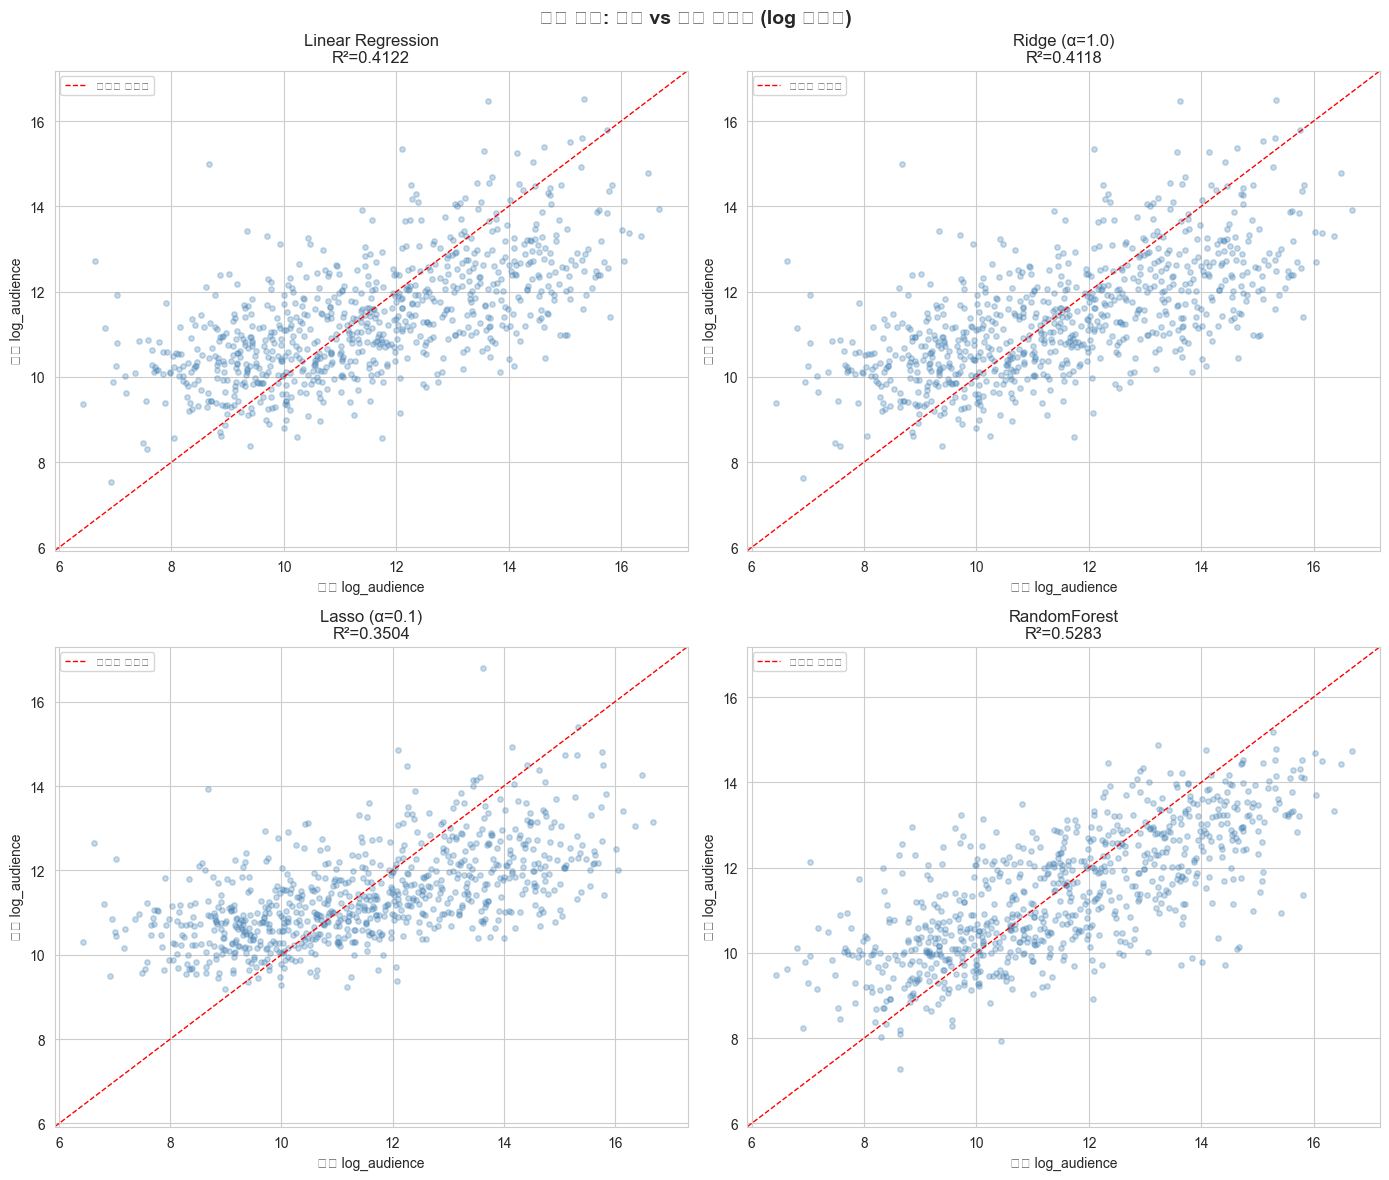

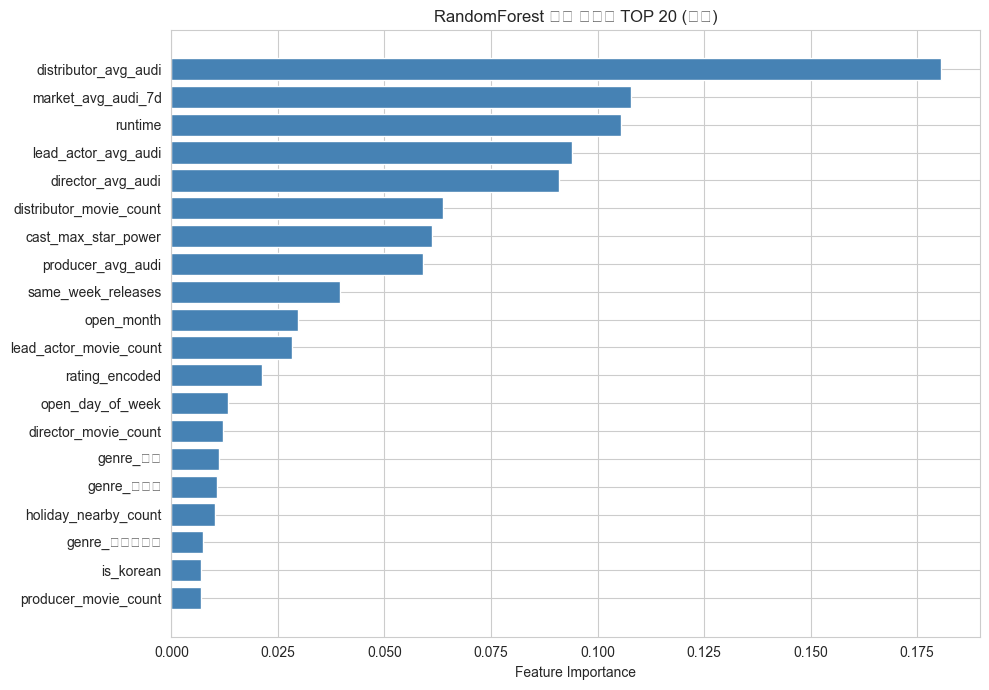

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('회귀 모델: 실제 vs 예측 관객수 (log 스케일)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (name, res) in zip(axes, reg_results.items()):
    pred = res['pipe'].predict(X_test)
    ax.scatter(yr_test, pred, alpha=0.3, s=15, color='steelblue')
    lim = [min(yr_test.min(), pred.min()) - 0.5,
           max(yr_test.max(), pred.max()) + 0.5]
    ax.plot(lim, lim, 'r--', linewidth=1, label='완벽한 예측선')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('실제 log_audience')
    ax.set_ylabel('예측 log_audience')
    ax.set_title(f'{name}\nR²={res["R²"]:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/06_regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# 피처 중요도 (RandomForest)
rf_pipe   = reg_results['RandomForest']['pipe']
ohe_cols  = rf_pipe['pre'].named_transformers_['cat'].get_feature_names_out(CAT_COLS).tolist()
all_feats = NUM_COLS + ohe_cols
importances = rf_pipe['model'].feature_importances_

df_imp = pd.DataFrame({'feature': all_feats, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_imp['feature'], df_imp['importance'], color='steelblue')
ax.set_title('RandomForest 피처 중요도 TOP 20 (회귀)', fontsize=12)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/07_rf_feature_importance_reg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 셀 10. 분류 모델 학습 (Logistic / RandomForest)

타겟: `hit_class` (0~3)  
불균형 대응: `class_weight='balanced'`

In [14]:
cls_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cls_results = {}

for name, model in cls_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, yc_train)
    pred = pipe.predict(X_test)
    cls_results[name] = {'pipe': pipe, 'pred': pred}

    print(f'\n=== {name} ===')
    print(classification_report(
        yc_test, pred,
        target_names=['0(~10만)','1(10만~100만)','2(100만~500만)','3(500만~)']
    ))


=== Logistic Regression ===
              precision    recall  f1-score   support

     0(~10만)       0.76      0.76      0.76       402
 1(10만~100만)       0.46      0.35      0.40       245
2(100만~500만)       0.34      0.37      0.35       113
    3(500만~)       0.15      0.52      0.23        21

    accuracy                           0.57       781
   macro avg       0.43      0.50      0.44       781
weighted avg       0.59      0.57      0.57       781


=== RandomForest ===
              precision    recall  f1-score   support

     0(~10만)       0.71      0.88      0.79       402
 1(10만~100만)       0.46      0.40      0.43       245
2(100만~500만)       0.43      0.27      0.34       113
    3(500만~)       0.00      0.00      0.00        21

    accuracy                           0.62       781
   macro avg       0.40      0.39      0.39       781
weighted avg       0.57      0.62      0.59       781



---
## 📊 셀 11. 분류 결과 시각화 (Confusion Matrix)

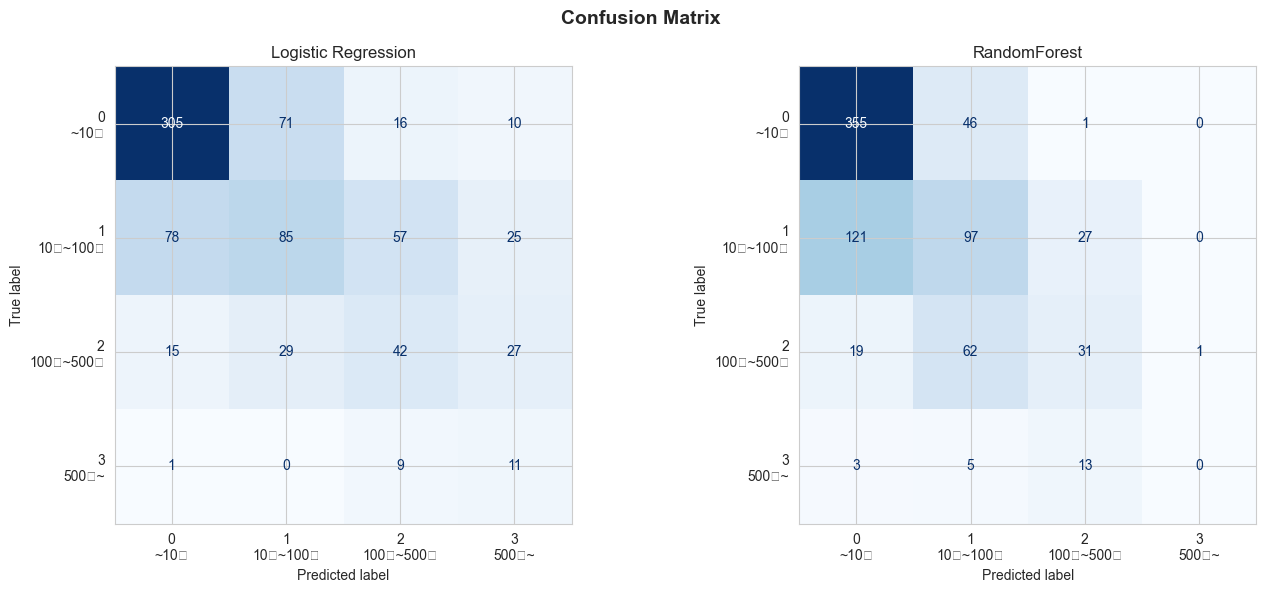

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')
class_names = ['0\n~10만','1\n10만~100만','2\n100만~500만','3\n500만~']

for ax, (name, res) in zip(axes, cls_results.items()):
    cm = confusion_matrix(yc_test, res['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📝 셀 12. 결과 요약 (보고서용)

> 이 셀의 수치를 실제 실행 결과로 업데이트하여 보고서에 붙여넣으세요.

In [16]:
print('=' * 60)
print('결과서용 요약 (01_eda_baseline.ipynb)')
print('=' * 60)

print('\n[데이터 개요]')
print(f'  - 사용 버전   : feature_table_{VERSION}.csv')
print(f'  - 전체 샘플   : {len(df)}편')
print(f'  - 피처 수     : {len(FEATURE_COLS)}개 (수치형 {len(NUM_COLS)} + 범주형 {len(CAT_COLS)})')
print(f'  - train/test  : {len(X_train)} / {len(X_test)}')

print('\n[회귀 결과 — 타겟: log_audience]')
for name, res in reg_results.items():
    print(f'  {name:<25} R²={res["R²"]:.4f}  MAE(실제)={res["MAE(실제)"]/1e4:.1f}만명')

print('\n[분류 결과 — 타겟: hit_class, metric: macro F1]')
for name, res in cls_results.items():
    from sklearn.metrics import f1_score
    f1 = f1_score(yc_test, res['pred'], average='macro')
    print(f'  {name:<25} macro F1={f1:.4f}')

print('\n[주요 인사이트 — EDA]')
best_genre = df.groupby('genre')['total_audience'].mean().idxmax()
print(f'  - 평균 관객수 1위 장르 : {best_genre}')
print(f'  - 한국 영화 평균       : {df[df["is_korean"]==1]["total_audience"].mean()/1e4:.1f}만명')
print(f'  - 외국 영화 평균       : {df[df["is_korean"]==0]["total_audience"].mean()/1e4:.1f}만명')
print(f'  - log_audience와 가장 상관 높은 피처 : {corr_target.abs().idxmax()}')
print('=' * 60)

결과서용 요약 (01_eda_baseline.ipynb)

[데이터 개요]
  - 사용 버전   : feature_table_v1.csv
  - 전체 샘플   : 3904편
  - 피처 수     : 21개 (수치형 20 + 범주형 1)
  - train/test  : 3123 / 781

[회귀 결과 — 타겟: log_audience]
  Linear Regression         R²=0.4122  MAE(실제)=60.8만명
  Ridge (α=1.0)             R²=0.4118  MAE(실제)=60.8만명
  Lasso (α=0.1)             R²=0.3504  MAE(실제)=61.2만명
  RandomForest              R²=0.5283  MAE(실제)=53.3만명

[분류 결과 — 타겟: hit_class, metric: macro F1]
  Logistic Regression       macro F1=0.4363
  RandomForest              macro F1=0.3876

[주요 인사이트 — EDA]
  - 평균 관객수 1위 장르 : 사극
  - 한국 영화 평균       : 103.1만명
  - 외국 영화 평균       : 47.7만명
  - log_audience와 가장 상관 높은 피처 : lead_actor_avg_audi
